# Conditional Monte Carlo

Author: Fred J. Hickernell + ChatGPT

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\reals}{\mathbb{R}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/KeisterExample.ipynb?flush_cache=true)

In [8]:
# Colab-only setup
if "google.colab" in str(get_ipython()):
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop

### Import needed packages and initialize some parameters

In [9]:
import sys
import time
from pathlib import Path
import numpy as np, math
if not hasattr(np, "math"):
    np.math = math
from scipy import stats
from UniformSumDistribution import UniformSumDistribution
import qmcpy as qp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent  # Ensure repo root is on sys.path (for local 'classlib' and 'nbviz')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from classlib.options.asian import bm_transform, asian_arith_mean_call_payoff, price, price_rqmc
from classlib.plots import plot_middle_half_sample_mean, plot_multiple_middle_half_sample_means
import classlib.nbviz as nb
nb.init(use_tex=True)     # styling, Tol cycle, CSS
colors, TINY = nb.TOL_BRIGHT, nb.TINY

## Conditional Monte Carlo for Density Estimation
We want to estimate the probability density, $\varrho$, for $Y=f(\vX)$, where $\vX \sim \mathcal{U}[0,1]^d$. If one can identify an _increasing_ $g$ such that
$$
y = f(\vx) \iff x_1 = g(y; \vx_{2:d})
$$
Then
$$
\varrho(y) = \mathbb{E}[\varrho_{Y|\boldsymbol{X}_{2:d}}(y | \boldsymbol{x}_{2:d}) = \int_{[0,1]^{d-1}} g'(y; \vx) \, \mathrm{d} \vx
$$

### Set up sampling schemes

In [10]:
samplers = {
    "iid":    {"gen": lambda d, n: qp.IIDStdUniform(d).gen_samples(n), "label": "IID"},
    "sobol":  {"gen": lambda d, n: qp.Sobol(d).gen_samples(n),         "label": "Sobol'"},
    "lattice":{"gen": lambda d, n: qp.Lattice(d).gen_samples(n),       "label": "Lattice"},
    "halton": {"gen": lambda d, n: qp.Halton(d).gen_samples(n),        "label": "Halton"}
}

### Sum of uniforms is an [Irwin-Hall distribution](https://en.wikipedia.org/wiki/Irwin–Hall_distribution)

In [11]:
def sum_d_unif_case(restrict_domain = False): #Sum of uniform random variables
    '''
    restrict_domain is used if we want to restrict the sample space
    '''
    def f(x,d = 1,coord_wts = 1):  #this is used for kernel density estimation
        assert x.ndim > 1
        return x.sum(axis = -1)  #add the coordinates
    def gprime(x,yeval,d=2,coord_wts = 1): 
        if np.isscalar(coord_wts):  #format the coordinate weights to fit the dimension
            coord_wts = np.full(d, coord_wts)
        else:
            coord_wts = np.ravel(coord_wts)  # flatten safely
            m = coord_wts.size
            if m > d:             # too many → truncate
                coord_wts = coord_wts[:d]
            elif m < d:           # too few → pad with last value
                coord_wts = np.pad(coord_wts, (0, d - m), constant_values=coord_wts[-1])
        n_y = yeval.size
        n_x = x.shape[0]
        yminusf = (yeval.reshape(1,n_y) - f(x[:,:d-1],d-1,coord_wts[1:d]).reshape(n_x,1))/coord_wts[0]
        return ((yminusf >= 0) & (yminusf <= 1)).astype(float)    
    def density(y,d = 1,coord_wts = 1):
        return UniformSumDistribution(d).pdf(y)
    def y_domain(d, coord_wts):
        if restrict_domain:
            return np.array([0,d])
        else:
            return np.array([-np.inf,np.inf])
    return {"f" : f,       #return a dictionary
            "gprime" : gprime,   #the function g' used for conditional Monte Carlo
            "density" : density,  #probability density of f(X) where X is IID U([0,1]^d)
            "y_plt_domain" : lambda d,coord_wts : np.array([-0.1,d+0.1]),  #domain for plotting the density
            "y_domain" : y_domain,  #sample space of Y = f(X)
            "name" : lambda d,coord_wts : f"Sum of {d:.0f} unif",  #Plot label for density
            "d_allowed" : [float('inf')]
    }

### Define a conditional Monte Carlo Estimator

In [12]:
def cmc(gprime, xdata, yeval = np.array([0]),**dens_kwargs):
    cmc_est = np.mean(gprime(xdata,yeval,**dens_kwargs), axis = 0)
    return np.mean(gprime(xdata,yeval,**dens_kwargs), axis = 0)

### Compute different kinds of error

In [13]:
def error_rho(rhoexact,rhoapp,kind_of_err = ["rmse"]):  #Compute different error measures for the CMC density estimation
    err_out = dict.fromkeys(kind_of_err)
    ''' 
    In this dictionary output
                          key = kind of error measure
        0th entry in the list = where the best bandwidth occurs
        1st entry in the list = best bandwidth
        2nd entry in the list = best error
        rest of the entries   = errors of all bandwidths
    '''
    err_rho = rhoexact - rhoapp  #pointwise error
    if "rmse" in kind_of_err:  #root mean squared error                           
        err_out["rmse"] = np.sqrt((err_rho**2).mean())
    if "mae" in kind_of_err:  #mean absolute error
        err_out["mae"] = np.abs(err_rho).mean()
    if "sup" in kind_of_err:  #supremum or maximum of error
        err_out["sup"] = np.abs(err_rho).max() 
    return err_out

### A small experiment

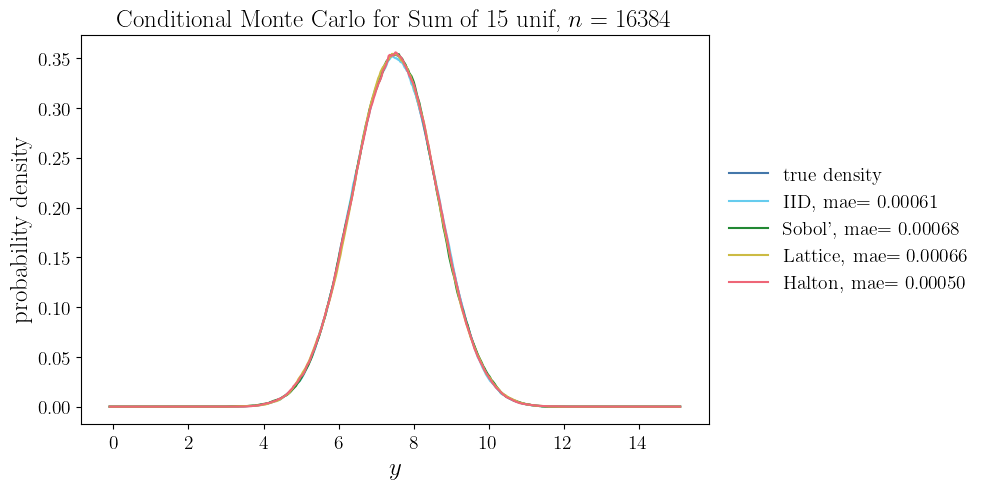

In [14]:
n = 2**14  #number of samples
d = 15   #dimension
sampler_list = ["iid", "sobol"]
nplot = 500 #number of points to plot the density at
wh_err = "mae"
coord_wts = np.ones(d)
#coord_wts = np.array(range(1,d+1))**-1.  later
#coord_wts = np.array(range(d,0,-1))**-1.
#print(coord_wts)
dens_kwargs = {"d" : d, "coord_wts" : coord_wts}

fig,ax = plt.subplots(1,figsize=(10,5))
ex_density = sum_d_unif_case(False)
plt_domain = ex_density["y_plt_domain"](**dens_kwargs) 
the_y_domain = ex_density["y_domain"](**dens_kwargs)
yplot = np.linspace(plt_domain[0],plt_domain[1],nplot)
rhoexact = ex_density["density"](yplot,**dens_kwargs)
ax.plot(yplot, rhoexact, label = "true density")
f = ex_density["f"]
#ypts = f(x,**dens_kwargs)  #construct all data points for all repetitions
for key in samplers:
    x = samplers[key]["gen"](d,n)  #choose a sampler
    ypts = f(x,**dens_kwargs)  #construct all data points for all repetitions
    rhoapp_cmc = cmc(ex_density["gprime"],x,yplot,**dens_kwargs)  #cmc estimate
    err_cmc = error_rho(rhoexact,rhoapp_cmc,kind_of_err = [wh_err])  #find error
    ax.plot(yplot,rhoapp_cmc, label = f'{samplers[key]["label"]}, {wh_err}$ = {err_cmc[wh_err]:.5f}$')

ax.set_title(f'Conditional Monte Carlo for {ex_density["name"](**dens_kwargs):s}, $n = {n:.0f}$')
ax.set_xlabel("$y$")
ax.set_ylabel("probability density")
ax.legend(
    loc="center left",           # anchor the legend’s left center
    bbox_to_anchor=(1.02, 0.5),  # x=1.02 means just outside right edge
    borderaxespad=0,             # optional: remove extra padding
    frameon=False                # optional: no box
)
fig.tight_layout()